# Center Correction Workbench

This notebook tests a replacement center-correction method for reference targets.

Compared sets:
- raw: `Registration/reference/targets3d.json`
- cpp: `Registration/reference/targets3d_adjust.json`
- notebook: local replacement method tested in this notebook

Current notebook method:
- use raw only as a local search anchor
- extract a larger ROI around the raw center
- project the ROI to a local plane
- build a grayscale raster from point-cloud intensity
- generate square candidates from Hough line pairs
- keep the square whose edge contrast matches the inner black square
- use that inner-black-square center as the notebook result

Notes:
- this notebook does not use `reference_targets.json`
- the debug view keeps the marker pattern visible
- raw, cpp, and notebook are shown in the same local frame


In [522]:
from pathlib import Path
import itertools
import json
import math

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from skimage.feature import canny
from skimage.transform import hough_line, hough_line_peaks

try:
    import pandas as pd
except Exception:
    pd = None

plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 11
plt.rcParams["axes.titlesize"] = 12

DETECTION = Path.cwd()
if not (DETECTION / "cpp").exists():
    DETECTION = Path(r"D:\Conda_envs\TargetDetection\Detection")

SET_DIR = DETECTION / "sample_set2" / "set2_3m"
TARGET_TYPE = "reference"
TARGET_SIZE_CM = 17.0  # inner black square size
SQUARE_SIDE_PRIOR_CM = TARGET_SIZE_CM
DEBUG_DIR = SET_DIR / "Registration" / TARGET_TYPE / "debug"
DEBUG_DIR.mkdir(parents=True, exist_ok=True)

REFERENCE_CLOUD_PATH = SET_DIR / "Alignment" / "reference" / "reference_alignment_input.ply"
RAW_PATH = SET_DIR / "Registration" / TARGET_TYPE / "targets3d.json"
CPP_PATH = SET_DIR / "Registration" / TARGET_TYPE / "targets3d_adjust.json"
NOTEBOOK_JSON_PATH = DEBUG_DIR / "targets3d_adjust_notebook.json"
NOTEBOOK_DEBUG_PATH = DEBUG_DIR / "targets3d_adjust_notebook_debug.json"

print("DETECTION:", DETECTION)
print("SET_DIR  :", SET_DIR)
print("TARGET   :", TARGET_TYPE)
print("CLOUD    :", REFERENCE_CLOUD_PATH)
print("RAW      :", RAW_PATH)
print("CPP      :", CPP_PATH)
print("TARGET_SIZE_CM (inner black square):", TARGET_SIZE_CM)
print("SQUARE_SIDE_PRIOR_CM:", SQUARE_SIDE_PRIOR_CM)


DETECTION: d:\Conda_envs\TargetDetection\Detection
SET_DIR  : d:\Conda_envs\TargetDetection\Detection\sample_set2\set2_3m
TARGET   : reference
CLOUD    : d:\Conda_envs\TargetDetection\Detection\sample_set2\set2_3m\Alignment\reference\reference_alignment_input.ply
RAW      : d:\Conda_envs\TargetDetection\Detection\sample_set2\set2_3m\Registration\reference\targets3d.json
CPP      : d:\Conda_envs\TargetDetection\Detection\sample_set2\set2_3m\Registration\reference\targets3d_adjust.json
TARGET_SIZE_CM (inner black square): 17.0
SQUARE_SIDE_PRIOR_CM: 17.0


In [523]:
def load_json(path: Path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def load_centers_json(path: Path):
    data = load_json(path)
    out = {}
    for item in data:
        target_id = str(item.get("id", "")).strip()
        center = item.get("center", None)
        if not target_id or center is None or len(center) < 3:
            continue
        out[target_id] = np.asarray(center[:3], dtype=np.float32)
    return out


def save_centers_json(path: Path, centers: dict):
    payload = []
    for target_id in sorted(centers.keys()):
        center = np.asarray(centers[target_id], dtype=float).tolist()
        payload.append({"id": target_id, "center": center})
    with open(path, "w", encoding="utf-8") as f:
        json.dump(payload, f, indent=2)
    print("saved:", path)


def save_debug_json(path: Path, payload):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(payload, f, indent=2)
    print("saved:", path)


def show_rows(rows, sort_by=None, ascending=True, max_rows=200):
    if not rows:
        print("No rows")
        return None
    if pd is None:
        if sort_by is not None:
            rows = sorted(rows, key=lambda x: x.get(sort_by, 0), reverse=not ascending)
        for row in rows[:max_rows]:
            print(row)
        return rows
    df = pd.DataFrame(rows)
    if sort_by is not None and sort_by in df.columns:
        df = df.sort_values(sort_by, ascending=ascending)
    display(df.head(max_rows))
    return df

In [524]:
PLY_TYPE_MAP = {
    "char": "i1",
    "uchar": "u1",
    "short": "i2",
    "ushort": "u2",
    "int": "i4",
    "uint": "u4",
    "float": "f4",
    "float32": "f4",
    "double": "f8",
    "float64": "f8",
}


def read_ply_vertices(path: Path):
    with open(path, "rb") as f:
        header_lines = []
        while True:
            line = f.readline()
            if not line:
                raise ValueError(f"Invalid PLY header: {path}")
            line_text = line.decode("ascii", errors="replace").rstrip("\r\n")
            header_lines.append(line_text)
            if line_text == "end_header":
                break

        fmt = None
        vertex_count = None
        props = []
        in_vertex = False
        for line in header_lines:
            parts = line.split()
            if not parts:
                continue
            if parts[0] == "format":
                fmt = parts[1]
            elif parts[0] == "element":
                in_vertex = parts[1] == "vertex"
                if in_vertex:
                    vertex_count = int(parts[2])
                    props = []
            elif parts[0] == "property" and in_vertex:
                if parts[1] == "list":
                    raise NotImplementedError("PLY list properties are not supported in this notebook")
                props.append((parts[1], parts[2]))

        if fmt is None or vertex_count is None:
            raise ValueError(f"PLY header is missing format or vertex count: {path}")

        if fmt == "ascii":
            cols = {name: [] for _, name in props}
            for _ in range(vertex_count):
                values = f.readline().decode("ascii", errors="replace").strip().split()
                if not values:
                    continue
                for (_, name), value in zip(props, values):
                    cols[name].append(float(value))
            return {k: np.asarray(v, dtype=np.float32) for k, v in cols.items()}

        if fmt != "binary_little_endian":
            raise NotImplementedError(f"Unsupported PLY format: {fmt}")

        dtype = np.dtype([(name, "<" + PLY_TYPE_MAP[ptype]) for ptype, name in props])
        data = np.fromfile(f, dtype=dtype, count=vertex_count)
        out = {}
        for _, name in props:
            arr = data[name]
            out[name] = arr.astype(np.float32) if arr.dtype.kind in "iuIf" else arr
        return out


def load_point_cloud(path: Path):
    raw = read_ply_vertices(path)
    xyz = np.column_stack([
        raw.get("x", np.array([], dtype=np.float32)),
        raw.get("y", np.array([], dtype=np.float32)),
        raw.get("z", np.array([], dtype=np.float32)),
    ]).astype(np.float32)
    intensity = raw.get("intensity", np.zeros(len(xyz), dtype=np.float32)).astype(np.float32)
    return {
        "xyz": xyz,
        "intensity": intensity,
        "raw": raw,
        "path": path,
    }

In [525]:
def build_compare_table(raw: dict, cpp_adjust: dict, notebook_candidate=None, notebook_debug=None):
    ids = sorted(set(raw.keys()) | set(cpp_adjust.keys()) | (set(notebook_candidate.keys()) if notebook_candidate else set()))
    rows = []
    for target_id in ids:
        row = {"id": target_id}
        row["raw_cpp_delta_mm"] = float(np.linalg.norm(raw[target_id] - cpp_adjust[target_id]) * 1000.0) if target_id in raw and target_id in cpp_adjust else np.nan
        row["raw_notebook_delta_mm"] = float(np.linalg.norm(raw[target_id] - notebook_candidate[target_id]) * 1000.0) if notebook_candidate is not None and target_id in raw and target_id in notebook_candidate else np.nan
        row["cpp_notebook_delta_mm"] = float(np.linalg.norm(cpp_adjust[target_id] - notebook_candidate[target_id]) * 1000.0) if notebook_candidate is not None and target_id in cpp_adjust and target_id in notebook_candidate else np.nan
        if notebook_debug is not None and target_id in notebook_debug:
            dbg = notebook_debug[target_id]
            row["accepted"] = int(bool(dbg.get("accepted", False)))
            row["roi_points"] = int(dbg.get("roi_points", 0))
            row["square_size_px"] = float(dbg.get("square_size_px", np.nan))
            row["square_size_cm"] = float(dbg.get("square_size_cm", np.nan))
            row["square_aspect"] = float(dbg.get("square_aspect", np.nan))
            row["dist_raw_px"] = float(dbg.get("dist_raw_px", np.nan))
            row["inner_contrast"] = float(dbg.get("inner_contrast", np.nan))
            row["inside_mean"] = float(dbg.get("inside_mean", np.nan))
            row["outside_mean"] = float(dbg.get("outside_mean", np.nan))
            row["orth_err_deg"] = float(dbg.get("orth_err_deg", np.nan))
            row["hough_strength"] = float(dbg.get("hough_strength", np.nan))
            row["delta_from_raw_mm"] = float(dbg.get("delta_mm", 0.0))
            row["reason"] = dbg.get("reason", "")
        rows.append(row)
    return rows


In [526]:
cloud = load_point_cloud(REFERENCE_CLOUD_PATH)
raw_centers = load_centers_json(RAW_PATH)
cpp_centers = load_centers_json(CPP_PATH)

print("cloud points:", len(cloud["xyz"]))
print("raw centers :", len(raw_centers))
print("cpp centers :", len(cpp_centers))

baseline_rows = build_compare_table(raw_centers, cpp_centers)
show_rows(baseline_rows, sort_by="raw_cpp_delta_mm", ascending=False)

cloud points: 519304
raw centers : 4
cpp centers : 4
{'id': 'T001', 'raw_cpp_delta_mm': 25.021705627441406, 'raw_notebook_delta_mm': nan, 'cpp_notebook_delta_mm': nan}
{'id': 'T003', 'raw_cpp_delta_mm': 21.68436050415039, 'raw_notebook_delta_mm': nan, 'cpp_notebook_delta_mm': nan}
{'id': 'T004', 'raw_cpp_delta_mm': 17.03411865234375, 'raw_notebook_delta_mm': nan, 'cpp_notebook_delta_mm': nan}
{'id': 'T002', 'raw_cpp_delta_mm': 12.390338897705078, 'raw_notebook_delta_mm': nan, 'cpp_notebook_delta_mm': nan}


[{'id': 'T001',
  'raw_cpp_delta_mm': 25.021705627441406,
  'raw_notebook_delta_mm': nan,
  'cpp_notebook_delta_mm': nan},
 {'id': 'T003',
  'raw_cpp_delta_mm': 21.68436050415039,
  'raw_notebook_delta_mm': nan,
  'cpp_notebook_delta_mm': nan},
 {'id': 'T004',
  'raw_cpp_delta_mm': 17.03411865234375,
  'raw_notebook_delta_mm': nan,
  'cpp_notebook_delta_mm': nan},
 {'id': 'T002',
  'raw_cpp_delta_mm': 12.390338897705078,
  'raw_notebook_delta_mm': nan,
  'cpp_notebook_delta_mm': nan}]

In [527]:
PARAMS = {
    "target_size_cm": TARGET_SIZE_CM,
    "square_side_prior_cm": SQUARE_SIDE_PRIOR_CM,
    "square_side_tolerance_cm": 0.5,
    "roi_margin_cm": 5.0,
    "roi_scale": 1.00,
    "roi_try_offsets_cm": [2.0, 5.0, 0.0],
    "q_low": 0.02,
    "q_high": 0.98,
    "q_clip": 0.99,
    "min_roi_points": 80,
    "movement_cap_mm": 80.0,
    "min_update_mm": 1.0,
    "raster_cell_mm": 2.0,
    "raster_min_size": 128,
    "raster_max_size": 640,
    "blur_iterations": 2,
    "canny_sigma": 1.2,
    "canny_low_threshold": 0.15,
    "canny_high_threshold": 0.35,
    "hough_num_peaks": 30,
    "hough_angle_tol_deg": 5.0,
    "hough_orth_tol_deg": 8.0,
    "min_pair_sep_px": 20.0,
    "max_square_aspect": 1.18,
    "square_aspect_penalty": 1.8,
    "edge_inside_offset_px": 4.0,
    "edge_outside_offset_px": 4.0,
    "edge_sample_start": 0.15,
    "edge_sample_end": 0.85,
    "edge_sample_count": 21,
    "inner_contrast_min": 0.02,
    "inner_contrast_weight": 5.0,
    "square_side_penalty": 0.25,
    "raw_distance_penalty": 0.015,
}


def roi_radius_base_cm(target_size_cm: float, margin_cm: float, scale: float):
    diag_half = 0.707 * target_size_cm
    return max(scale * target_size_cm, diag_half + margin_cm)


def extract_roi(cloud_data: dict, center_xyz, radius_cm: float):
    xyz = cloud_data["xyz"]
    intensity = cloud_data["intensity"]
    center_xyz = np.asarray(center_xyz, dtype=np.float32)
    radius_m = radius_cm / 100.0
    d2 = np.sum((xyz - center_xyz[None, :]) ** 2, axis=1)
    mask = d2 <= radius_m ** 2
    return {
        "xyz": xyz[mask],
        "intensity": intensity[mask],
        "center_prev": center_xyz,
        "radius_cm": radius_cm,
    }


def normalize_intensity(values, q_low=0.02, q_high=0.98, q_clip=0.99):
    values = np.asarray(values, dtype=np.float32)
    if len(values) == 0:
        return values, 0.0, 1.0, 1.0
    lo = float(np.quantile(values, q_low))
    hi = float(np.quantile(values, q_high))
    if hi <= lo:
        lo = float(values.min())
        hi = float(values.max())
        if hi <= lo:
            hi = lo + 1e-6
    clip_hi = float(np.quantile(values, q_clip))
    clamped = np.minimum(values, clip_hi)
    norm = np.clip((clamped - lo) / max(hi - lo, 1e-6), 0.0, 1.0)
    return norm, lo, hi, clip_hi


def fit_plane_pca(points_xyz: np.ndarray):
    if len(points_xyz) < 3:
        return None
    mean = points_xyz.mean(axis=0)
    X = points_xyz - mean[None, :]
    _, _, vh = np.linalg.svd(X, full_matrices=False)
    return {
        "mean": mean.astype(np.float32),
        "u": vh[0].astype(np.float32),
        "v": vh[1].astype(np.float32),
        "n": vh[2].astype(np.float32),
    }


def world_to_uv(points_xyz: np.ndarray, plane: dict):
    pts = np.asarray(points_xyz, dtype=np.float32)
    if pts.ndim == 1:
        pts = pts[None, :]
    d = pts - plane["mean"][None, :]
    U = d @ plane["u"]
    V = d @ plane["v"]
    return np.column_stack([U, V]).astype(np.float32)


def uv_to_world(uv, plane: dict):
    uv = np.asarray(uv, dtype=np.float32)
    return plane["mean"] + uv[0] * plane["u"] + uv[1] * plane["v"]


def rasterize_intensity_uv(uv: np.ndarray, norm_values: np.ndarray, cell_mm: float, min_size: int, max_size: int):
    if len(uv) == 0:
        return None
    umin = float(np.min(uv[:, 0]))
    umax = float(np.max(uv[:, 0]))
    vmin = float(np.min(uv[:, 1]))
    vmax = float(np.max(uv[:, 1]))
    cell_m = cell_mm / 1000.0
    width = int(np.clip(np.round((umax - umin) / max(cell_m, 1e-6)), min_size, max_size))
    height = int(np.clip(np.round((vmax - vmin) / max(cell_m, 1e-6)), min_size, max_size))
    width = max(width, 2)
    height = max(height, 2)

    x = np.clip(np.floor((uv[:, 0] - umin) / max(umax - umin, 1e-6) * (width - 1)).astype(int), 0, width - 1)
    y = np.clip(np.floor((uv[:, 1] - vmin) / max(vmax - vmin, 1e-6) * (height - 1)).astype(int), 0, height - 1)

    sum_img = np.zeros((height, width), dtype=np.float32)
    count_img = np.zeros((height, width), dtype=np.int32)
    np.add.at(sum_img, (y, x), norm_values)
    np.add.at(count_img, (y, x), 1)

    valid_mask = count_img > 0
    gray = np.ones((height, width), dtype=np.float32)
    gray[valid_mask] = sum_img[valid_mask] / np.maximum(count_img[valid_mask], 1)

    return {
        "gray": gray,
        "valid_mask": valid_mask,
        "box": {"umin": umin, "umax": umax, "vmin": vmin, "vmax": vmax, "width": width, "height": height},
    }


def uv_to_pixel(uv: np.ndarray, box: dict):
    uv = np.asarray(uv, dtype=np.float32)
    if uv.ndim == 1:
        uv = uv[None, :]
    width = max(box["width"] - 1, 1)
    height = max(box["height"] - 1, 1)
    x = (uv[:, 0] - box["umin"]) / max(box["umax"] - box["umin"], 1e-6) * width
    y = (uv[:, 1] - box["vmin"]) / max(box["vmax"] - box["vmin"], 1e-6) * height
    return np.column_stack([x, y]).astype(np.float32)


def pixel_to_uv(px: np.ndarray, box: dict):
    px = np.asarray(px, dtype=np.float32)
    if px.ndim == 1:
        px = px[None, :]
    width = max(box["width"] - 1, 1)
    height = max(box["height"] - 1, 1)
    u = box["umin"] + (px[:, 0] / width) * (box["umax"] - box["umin"])
    v = box["vmin"] + (px[:, 1] / height) * (box["vmax"] - box["vmin"])
    return np.column_stack([u, v]).astype(np.float32)


def box_blur(image: np.ndarray, iterations: int = 1):
    out = image.astype(np.float32)
    for _ in range(iterations):
        padded = np.pad(out, 1, mode="edge")
        acc = np.zeros_like(out, dtype=np.float32)
        for dy in range(3):
            for dx in range(3):
                acc += padded[dy:dy + out.shape[0], dx:dx + out.shape[1]]
        out = acc / 9.0
    return out


def sample_gray_bilinear(gray: np.ndarray, pts: np.ndarray):
    h, w = gray.shape
    x = pts[:, 0]
    y = pts[:, 1]
    x0 = np.floor(x).astype(int)
    y0 = np.floor(y).astype(int)
    x1 = np.clip(x0 + 1, 0, w - 1)
    y1 = np.clip(y0 + 1, 0, h - 1)
    x0 = np.clip(x0, 0, w - 1)
    y0 = np.clip(y0, 0, h - 1)
    wx = x - x0
    wy = y - y0
    v00 = gray[y0, x0]
    v10 = gray[y0, x1]
    v01 = gray[y1, x0]
    v11 = gray[y1, x1]
    vals = (1.0 - wx) * (1.0 - wy) * v00 + wx * (1.0 - wy) * v10 + (1.0 - wx) * wy * v01 + wx * wy * v11
    ok = (pts[:, 0] >= 0) & (pts[:, 0] <= w - 1) & (pts[:, 1] >= 0) & (pts[:, 1] <= h - 1)
    return vals.astype(np.float32), ok


def angle_diff_deg(a_deg: float, b_deg: float):
    return abs(((a_deg - b_deg + 90.0) % 180.0) - 90.0)


def line_intersection(l1: dict, l2: dict):
    a1 = math.cos(l1["theta"])
    b1 = math.sin(l1["theta"])
    c1 = l1["dist"]
    a2 = math.cos(l2["theta"])
    b2 = math.sin(l2["theta"])
    c2 = l2["dist"]
    det = a1 * b2 - a2 * b1
    if abs(det) < 1e-6:
        return None
    x = (c1 * b2 - c2 * b1) / det
    y = (a1 * c2 - a2 * c1) / det
    return np.array([x, y], dtype=np.float32)


def measure_inner_square_contrast(gray: np.ndarray, poly: np.ndarray, params: dict):
    center = poly[:-1].mean(axis=0)
    inside_means = []
    outside_means = []
    sample_values = np.linspace(
        params["edge_sample_start"],
        params["edge_sample_end"],
        params["edge_sample_count"],
        dtype=np.float32,
    )

    for i in range(4):
        p0 = poly[i]
        p1 = poly[i + 1]
        edge = p1 - p0
        edge_len = float(np.linalg.norm(edge))
        if edge_len < 1e-6:
            continue

        tangent = edge / edge_len
        normal = np.array([-tangent[1], tangent[0]], dtype=np.float32)
        mid = 0.5 * (p0 + p1)
        if np.dot(normal, mid - center) < 0:
            normal = -normal

        base = p0[None, :] + sample_values[:, None] * edge[None, :]
        inside_pts = base - params["edge_inside_offset_px"] * normal[None, :]
        outside_pts = base + params["edge_outside_offset_px"] * normal[None, :]
        inside_vals, inside_ok = sample_gray_bilinear(gray, inside_pts)
        outside_vals, outside_ok = sample_gray_bilinear(gray, outside_pts)
        good = inside_ok & outside_ok
        if int(good.sum()) < max(8, params["edge_sample_count"] // 3):
            continue

        inside_means.append(float(inside_vals[good].mean()))
        outside_means.append(float(outside_vals[good].mean()))

    if not inside_means:
        return None

    inside_mean = float(np.mean(inside_means))
    outside_mean = float(np.mean(outside_means))
    return {
        "inside_mean": inside_mean,
        "outside_mean": outside_mean,
        "inner_contrast": float(outside_mean - inside_mean),
    }


def estimate_cm_per_px(box: dict):
    u_step_cm = 100.0 * (box["umax"] - box["umin"]) / max(box["width"] - 1, 1)
    v_step_cm = 100.0 * (box["vmax"] - box["vmin"]) / max(box["height"] - 1, 1)
    return 0.5 * (u_step_cm + v_step_cm)


def cluster_lines(lines, angle_tol_deg: float):
    clusters = []
    for line in sorted(lines, key=lambda item: item["acc"], reverse=True):
        placed = False
        for cluster in clusters:
            if angle_diff_deg(line["deg"], cluster[0]["deg"]) <= angle_tol_deg:
                cluster.append(line)
                placed = True
                break
        if not placed:
            clusters.append([line])
    clusters.sort(key=lambda cluster: sum(item["acc"] for item in cluster), reverse=True)
    return clusters


def search_square_from_hough(gray: np.ndarray, raw_px: np.ndarray, box: dict, params: dict):
    edges = canny(
        gray,
        sigma=params["canny_sigma"],
        low_threshold=params["canny_low_threshold"],
        high_threshold=params["canny_high_threshold"],
    )

    angle_values = np.deg2rad(np.arange(-90, 90, 1))
    hspace, theta_values, dist_values = hough_line(edges, theta=angle_values)
    accums, peak_thetas, peak_dists = hough_line_peaks(
        hspace,
        theta_values,
        dist_values,
        num_peaks=params["hough_num_peaks"],
    )

    lines = []
    for acc, theta, dist in zip(accums, peak_thetas, peak_dists):
        raw_proj = raw_px[0] * math.cos(theta) + raw_px[1] * math.sin(theta)
        lines.append({
            "acc": float(acc),
            "theta": float(theta),
            "deg": float(np.rad2deg(theta)),
            "dist": float(dist),
            "raw_offset": float(dist - raw_proj),
        })

    clusters = cluster_lines(lines, params["hough_angle_tol_deg"])
    cm_per_px = estimate_cm_per_px(box)
    best = None

    for i in range(len(clusters)):
        for j in range(i + 1, len(clusters)):
            ang_i = clusters[i][0]["deg"]
            ang_j = clusters[j][0]["deg"]
            orth_err = abs(angle_diff_deg(ang_i, ang_j) - 90.0)
            if orth_err > params["hough_orth_tol_deg"]:
                continue

            group_a = clusters[i]
            group_b = clusters[j]
            for line_a0, line_a1 in itertools.combinations(group_a, 2):
                raw_proj_a = raw_px[0] * math.cos(line_a0["theta"]) + raw_px[1] * math.sin(line_a0["theta"])
                if (line_a0["dist"] - raw_proj_a) * (line_a1["dist"] - raw_proj_a) > 0:
                    continue
                sep_a = abs(line_a0["dist"] - line_a1["dist"])
                if sep_a < params["min_pair_sep_px"]:
                    continue

                for line_b0, line_b1 in itertools.combinations(group_b, 2):
                    raw_proj_b = raw_px[0] * math.cos(line_b0["theta"]) + raw_px[1] * math.sin(line_b0["theta"])
                    if (line_b0["dist"] - raw_proj_b) * (line_b1["dist"] - raw_proj_b) > 0:
                        continue
                    sep_b = abs(line_b0["dist"] - line_b1["dist"])
                    if sep_b < params["min_pair_sep_px"]:
                        continue

                    aspect = max(sep_a, sep_b) / max(min(sep_a, sep_b), 1e-6)
                    if aspect > params["max_square_aspect"]:
                        continue

                    p00 = line_intersection(line_a0, line_b0)
                    p01 = line_intersection(line_a0, line_b1)
                    p11 = line_intersection(line_a1, line_b1)
                    p10 = line_intersection(line_a1, line_b0)
                    if p00 is None or p01 is None or p11 is None or p10 is None:
                        continue

                    corners = np.asarray([p00, p01, p11, p10], dtype=np.float32)
                    poly = np.vstack([corners, corners[:1]]).astype(np.float32)
                    center_px = corners.mean(axis=0)
                    height, width = gray.shape
                    if not (-0.10 * width <= center_px[0] <= 1.10 * width and -0.10 * height <= center_px[1] <= 1.10 * height):
                        continue

                    contrast_info = measure_inner_square_contrast(gray, poly, params)
                    if contrast_info is None:
                        continue
                    if contrast_info["inner_contrast"] < params["inner_contrast_min"]:
                        continue

                    square_size_px = float(0.5 * (sep_a + sep_b))
                    square_size_cm = float(square_size_px * cm_per_px)
                    if abs(square_size_cm - params["square_side_prior_cm"]) > params["square_side_tolerance_cm"]:
                        continue
                    dist_raw_px = float(np.linalg.norm(center_px - raw_px))
                    hough_strength = float(line_a0["acc"] + line_a1["acc"] + line_b0["acc"] + line_b1["acc"])
                    score = (
                        params["inner_contrast_weight"] * contrast_info["inner_contrast"]
                        - params["square_side_penalty"] * abs(square_size_cm - params["square_side_prior_cm"])
                        - params["square_aspect_penalty"] * abs(aspect - 1.0)
                        - params["raw_distance_penalty"] * dist_raw_px
                    )

                    candidate = {
                        "score": float(score),
                        "center_px": center_px.astype(np.float32),
                        "corners_px": poly,
                        "square_size_px": square_size_px,
                        "square_size_cm": square_size_cm,
                        "square_aspect": float(aspect),
                        "dist_raw_px": dist_raw_px,
                        "hough_strength": hough_strength,
                        "orth_err_deg": float(orth_err),
                        "inside_mean": contrast_info["inside_mean"],
                        "outside_mean": contrast_info["outside_mean"],
                        "inner_contrast": contrast_info["inner_contrast"],
                    }

                    if best is None or candidate["score"] > best["score"]:
                        best = candidate

    return {
        "candidate": best,
        "edges": edges.astype(np.uint8),
        "num_lines": int(len(lines)),
        "num_clusters": int(len(clusters)),
    }


def estimate_one_target(cloud_data: dict, prev_center, params: dict):
    base = roi_radius_base_cm(params["target_size_cm"], params["roi_margin_cm"], params["roi_scale"])
    last_result = None

    for offset in params["roi_try_offsets_cm"]:
        roi = extract_roi(cloud_data, prev_center, base + offset)
        result = {
            "ok": False,
            "accepted": False,
            "roi_radius_cm": base + offset,
            "roi_points": int(len(roi["xyz"])),
            "square_size_px": np.nan,
            "square_size_cm": np.nan,
            "square_aspect": np.nan,
            "dist_raw_px": np.nan,
            "inner_contrast": np.nan,
            "inside_mean": np.nan,
            "outside_mean": np.nan,
            "orth_err_deg": np.nan,
            "hough_strength": np.nan,
            "delta_mm": 0.0,
            "reason": "unknown",
            "center_prev": np.asarray(prev_center, dtype=np.float32),
            "center_candidate": np.asarray(prev_center, dtype=np.float32),
            "center_final": np.asarray(prev_center, dtype=np.float32),
            "roi": roi,
        }

        if len(roi["xyz"]) < params["min_roi_points"]:
            result["reason"] = "roi_too_small"
            last_result = result
            continue

        norm, lo, hi, clip_hi = normalize_intensity(
            roi["intensity"],
            q_low=params["q_low"],
            q_high=params["q_high"],
            q_clip=params["q_clip"],
        )
        plane = fit_plane_pca(roi["xyz"])
        if plane is None:
            result["reason"] = "plane_fit_failed"
            last_result = result
            continue

        roi_uv = world_to_uv(roi["xyz"], plane)
        raw_uv = world_to_uv(prev_center, plane)[0]
        raster_info = rasterize_intensity_uv(
            roi_uv,
            norm_values=norm,
            cell_mm=params["raster_cell_mm"],
            min_size=params["raster_min_size"],
            max_size=params["raster_max_size"],
        )
        if raster_info is None:
            result["reason"] = "raster_failed"
            last_result = result
            continue

        gray = raster_info["gray"]
        gray_smooth = box_blur(gray, iterations=params["blur_iterations"])
        raw_px = uv_to_pixel(raw_uv, raster_info["box"])[0]
        search = search_square_from_hough(gray_smooth, raw_px, raster_info["box"], params)
        selected = search["candidate"]

        result["plane"] = plane
        result["raster_gray"] = gray
        result["raster_gray_smooth"] = gray_smooth
        result["raster_valid_mask"] = raster_info["valid_mask"].astype(np.uint8)
        result["raster_edges"] = search["edges"]
        result["box"] = raster_info["box"]
        result["num_hough_lines"] = search["num_lines"]
        result["num_hough_clusters"] = search["num_clusters"]
        result["raw_px"] = raw_px.astype(np.float32)
        result["lo"] = lo
        result["hi"] = hi
        result["clip_hi"] = clip_hi

        if selected is None:
            result["reason"] = "no_inner_black_square"
            last_result = result
            continue

        center_uv = pixel_to_uv(selected["center_px"], raster_info["box"])[0]
        center_candidate = uv_to_world(center_uv, plane)
        delta_mm = float(np.linalg.norm(center_candidate - prev_center) * 1000.0)

        accepted = True
        center_final = center_candidate.copy()
        if delta_mm > params["movement_cap_mm"]:
            accepted = False
            center_final = np.asarray(prev_center, dtype=np.float32)
        if delta_mm < params["min_update_mm"]:
            accepted = False
            center_final = np.asarray(prev_center, dtype=np.float32)

        result.update({
            "ok": True,
            "accepted": bool(accepted),
            "delta_mm": delta_mm,
            "square_size_px": selected["square_size_px"],
            "square_size_cm": selected["square_size_cm"],
            "square_aspect": selected["square_aspect"],
            "dist_raw_px": selected["dist_raw_px"],
            "inner_contrast": selected["inner_contrast"],
            "inside_mean": selected["inside_mean"],
            "outside_mean": selected["outside_mean"],
            "orth_err_deg": selected["orth_err_deg"],
            "hough_strength": selected["hough_strength"],
            "center_candidate": center_candidate.astype(np.float32),
            "center_final": center_final.astype(np.float32),
            "selected_square_corners_px": selected["corners_px"],
            "selected_square_corners_uv": pixel_to_uv(selected["corners_px"], raster_info["box"]),
            "reason": "ok_inner_black_square",
        })
        return result

    return last_result


def run_notebook_candidate_all_targets(cloud_data: dict, raw: dict, params: dict):
    centers_out = {}
    debug = {}
    rows = []
    for target_id in sorted(raw.keys()):
        result = estimate_one_target(cloud_data, raw[target_id], params)
        debug[target_id] = result
        centers_out[target_id] = np.asarray(result["center_final"], dtype=np.float32)
        rows.append({
            "id": target_id,
            "ok": bool(result["ok"]),
            "accepted": bool(result["accepted"]),
            "reason": result["reason"],
            "roi_radius_cm": float(result["roi_radius_cm"]),
            "roi_points": int(result["roi_points"]),
            "square_size_px": float(result.get("square_size_px", np.nan)),
            "square_size_cm": float(result.get("square_size_cm", np.nan)),
            "square_aspect": float(result.get("square_aspect", np.nan)),
            "inner_contrast": float(result.get("inner_contrast", np.nan)),
            "dist_raw_px": float(result.get("dist_raw_px", np.nan)),
            "delta_from_raw_mm": float(result["delta_mm"]),
        })
    return centers_out, debug, rows


In [528]:
notebook_centers, notebook_debug, notebook_rows = run_notebook_candidate_all_targets(cloud, raw_centers, PARAMS)
show_rows(notebook_rows, sort_by="delta_from_raw_mm", ascending=False)

compare_rows = build_compare_table(raw_centers, cpp_centers, notebook_centers, notebook_debug)
show_rows(compare_rows, sort_by="cpp_notebook_delta_mm", ascending=False)

{'id': 'T001', 'ok': False, 'accepted': False, 'reason': 'no_inner_black_square', 'roi_radius_cm': 17.019, 'roi_points': 321, 'square_size_px': nan, 'square_size_cm': nan, 'square_aspect': nan, 'inner_contrast': nan, 'dist_raw_px': nan, 'delta_from_raw_mm': 0.0}
{'id': 'T002', 'ok': False, 'accepted': False, 'reason': 'no_inner_black_square', 'roi_radius_cm': 17.019, 'roi_points': 329, 'square_size_px': nan, 'square_size_cm': nan, 'square_aspect': nan, 'inner_contrast': nan, 'dist_raw_px': nan, 'delta_from_raw_mm': 0.0}
{'id': 'T003', 'ok': False, 'accepted': False, 'reason': 'no_inner_black_square', 'roi_radius_cm': 17.019, 'roi_points': 329, 'square_size_px': nan, 'square_size_cm': nan, 'square_aspect': nan, 'inner_contrast': nan, 'dist_raw_px': nan, 'delta_from_raw_mm': 0.0}
{'id': 'T004', 'ok': False, 'accepted': False, 'reason': 'no_inner_black_square', 'roi_radius_cm': 17.019, 'roi_points': 320, 'square_size_px': nan, 'square_size_cm': nan, 'square_aspect': nan, 'inner_contrast':

[{'id': 'T001',
  'raw_cpp_delta_mm': 25.021705627441406,
  'raw_notebook_delta_mm': 0.0,
  'cpp_notebook_delta_mm': 25.021705627441406,
  'accepted': 0,
  'roi_points': 321,
  'square_size_px': nan,
  'square_size_cm': nan,
  'square_aspect': nan,
  'dist_raw_px': nan,
  'inner_contrast': nan,
  'inside_mean': nan,
  'outside_mean': nan,
  'orth_err_deg': nan,
  'hough_strength': nan,
  'delta_from_raw_mm': 0.0,
  'reason': 'no_inner_black_square'},
 {'id': 'T003',
  'raw_cpp_delta_mm': 21.68436050415039,
  'raw_notebook_delta_mm': 0.0,
  'cpp_notebook_delta_mm': 21.68436050415039,
  'accepted': 0,
  'roi_points': 329,
  'square_size_px': nan,
  'square_size_cm': nan,
  'square_aspect': nan,
  'dist_raw_px': nan,
  'inner_contrast': nan,
  'inside_mean': nan,
  'outside_mean': nan,
  'orth_err_deg': nan,
  'hough_strength': nan,
  'delta_from_raw_mm': 0.0,
  'reason': 'no_inner_black_square'},
 {'id': 'T004',
  'raw_cpp_delta_mm': 17.03411865234375,
  'raw_notebook_delta_mm': 0.0,
  '

In [529]:
def show_all_target_debug(debug_results: dict, raw: dict, cpp_adjust: dict, notebook_candidate: dict, cols=2):
    ids = sorted(debug_results.keys())
    rows = math.ceil(len(ids) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(9 * cols, 6 * rows))
    axes = np.atleast_1d(axes).ravel()

    for ax in axes:
        ax.axis("off")

    for ax, target_id in zip(axes, ids):
        result = debug_results[target_id]
        ax.axis("on")

        gray = result.get("raster_gray", None)
        if gray is None:
            roi_xyz = result["roi"]["xyz"]
            if len(roi_xyz):
                ax.scatter(roi_xyz[:, 0], roi_xyz[:, 2], s=30, c="gray", alpha=0.5)
            title_line1 = f"{target_id} | failed"
            title_line2 = f"reason {result.get('reason', 'unknown')} | roi {result.get('roi_points', 0)}"
            ax.set_title(title_line1 + "\n" + title_line2, fontsize=10)
            ax.set_xlabel("X")
            ax.set_ylabel("Z")
            ax.axis("equal")
            continue

        box = result["box"]
        raw_px = uv_to_pixel(world_to_uv(raw[target_id], result["plane"])[0], box)[0] if target_id in raw else None
        cpp_px = uv_to_pixel(world_to_uv(cpp_adjust[target_id], result["plane"])[0], box)[0] if target_id in cpp_adjust else None
        nb_px = uv_to_pixel(world_to_uv(notebook_candidate[target_id], result["plane"])[0], box)[0] if target_id in notebook_candidate else None
        square_px = result.get("selected_square_corners_px", np.zeros((0, 2), dtype=np.float32))

        ax.imshow(gray, cmap="gray", origin="lower", vmin=0.0, vmax=1.0)

        if len(square_px):
            ax.plot(square_px[:, 0], square_px[:, 1], color="limegreen", linewidth=2.0, label="square")

        if raw_px is not None:
            ax.scatter(raw_px[0], raw_px[1], s=200, c="orange", marker="+", linewidths=2.5, label="raw")
        if cpp_px is not None:
            ax.scatter(cpp_px[0], cpp_px[1], s=100, c="deepskyblue", marker="x", linewidths=2.5, label="cpp")
        if nb_px is not None:
            ax.scatter(nb_px[0], nb_px[1], s=120, facecolors="none", edgecolors="magenta", marker="o", linewidths=2.0, label="template")

        valid = result["raster_valid_mask"].astype(bool)
        yy, xx = np.where(valid)
        if len(xx):
            xmin = float(np.min(xx))
            xmax = float(np.max(xx))
            ymin = float(np.min(yy))
            ymax = float(np.max(yy))
            dx = max(xmax - xmin, 1.0)
            dy = max(ymax - ymin, 1.0)
            mx = dx * 0.12
            my = dy * 0.12
            ax.set_xlim(xmin - mx, xmax + mx)
            ax.set_ylim(ymin - my, ymax + my)

        raw_cpp = np.linalg.norm(raw[target_id] - cpp_adjust[target_id]) * 1000.0 if target_id in raw and target_id in cpp_adjust else np.nan
        raw_nb = np.linalg.norm(raw[target_id] - notebook_candidate[target_id]) * 1000.0 if target_id in raw and target_id in notebook_candidate else np.nan
        cpp_nb = np.linalg.norm(cpp_adjust[target_id] - notebook_candidate[target_id]) * 1000.0 if target_id in cpp_adjust and target_id in notebook_candidate else np.nan

        title_line1 = f"{target_id} | raw-cpp {raw_cpp:.1f} mm | raw-nb {raw_nb:.1f} mm"
        title_line2 = f"cpp-nb {cpp_nb:.1f} mm | move {result.get('delta_mm', 0.0):.1f} mm | accepted {int(result.get('accepted', False))}"
        title_line3 = f"square {result.get('square_size_cm', np.nan):.2f} cm ({result.get('square_size_px', np.nan):.1f} px) | aspect {result.get('square_aspect', np.nan):.3f}"
        title_line4 = f"contrast {result.get('inner_contrast', np.nan):.3f} | inside {result.get('inside_mean', np.nan):.3f} | outside {result.get('outside_mean', np.nan):.3f}"
        ax.set_title(title_line1 + "\n" + title_line2 + "\n" + title_line3 + "\n" + title_line4, fontsize=10)
        ax.set_xlabel("u-pixel")
        ax.set_ylabel("v-pixel")
        ax.legend(loc="best", fontsize=8)

    plt.tight_layout()
    plt.show()


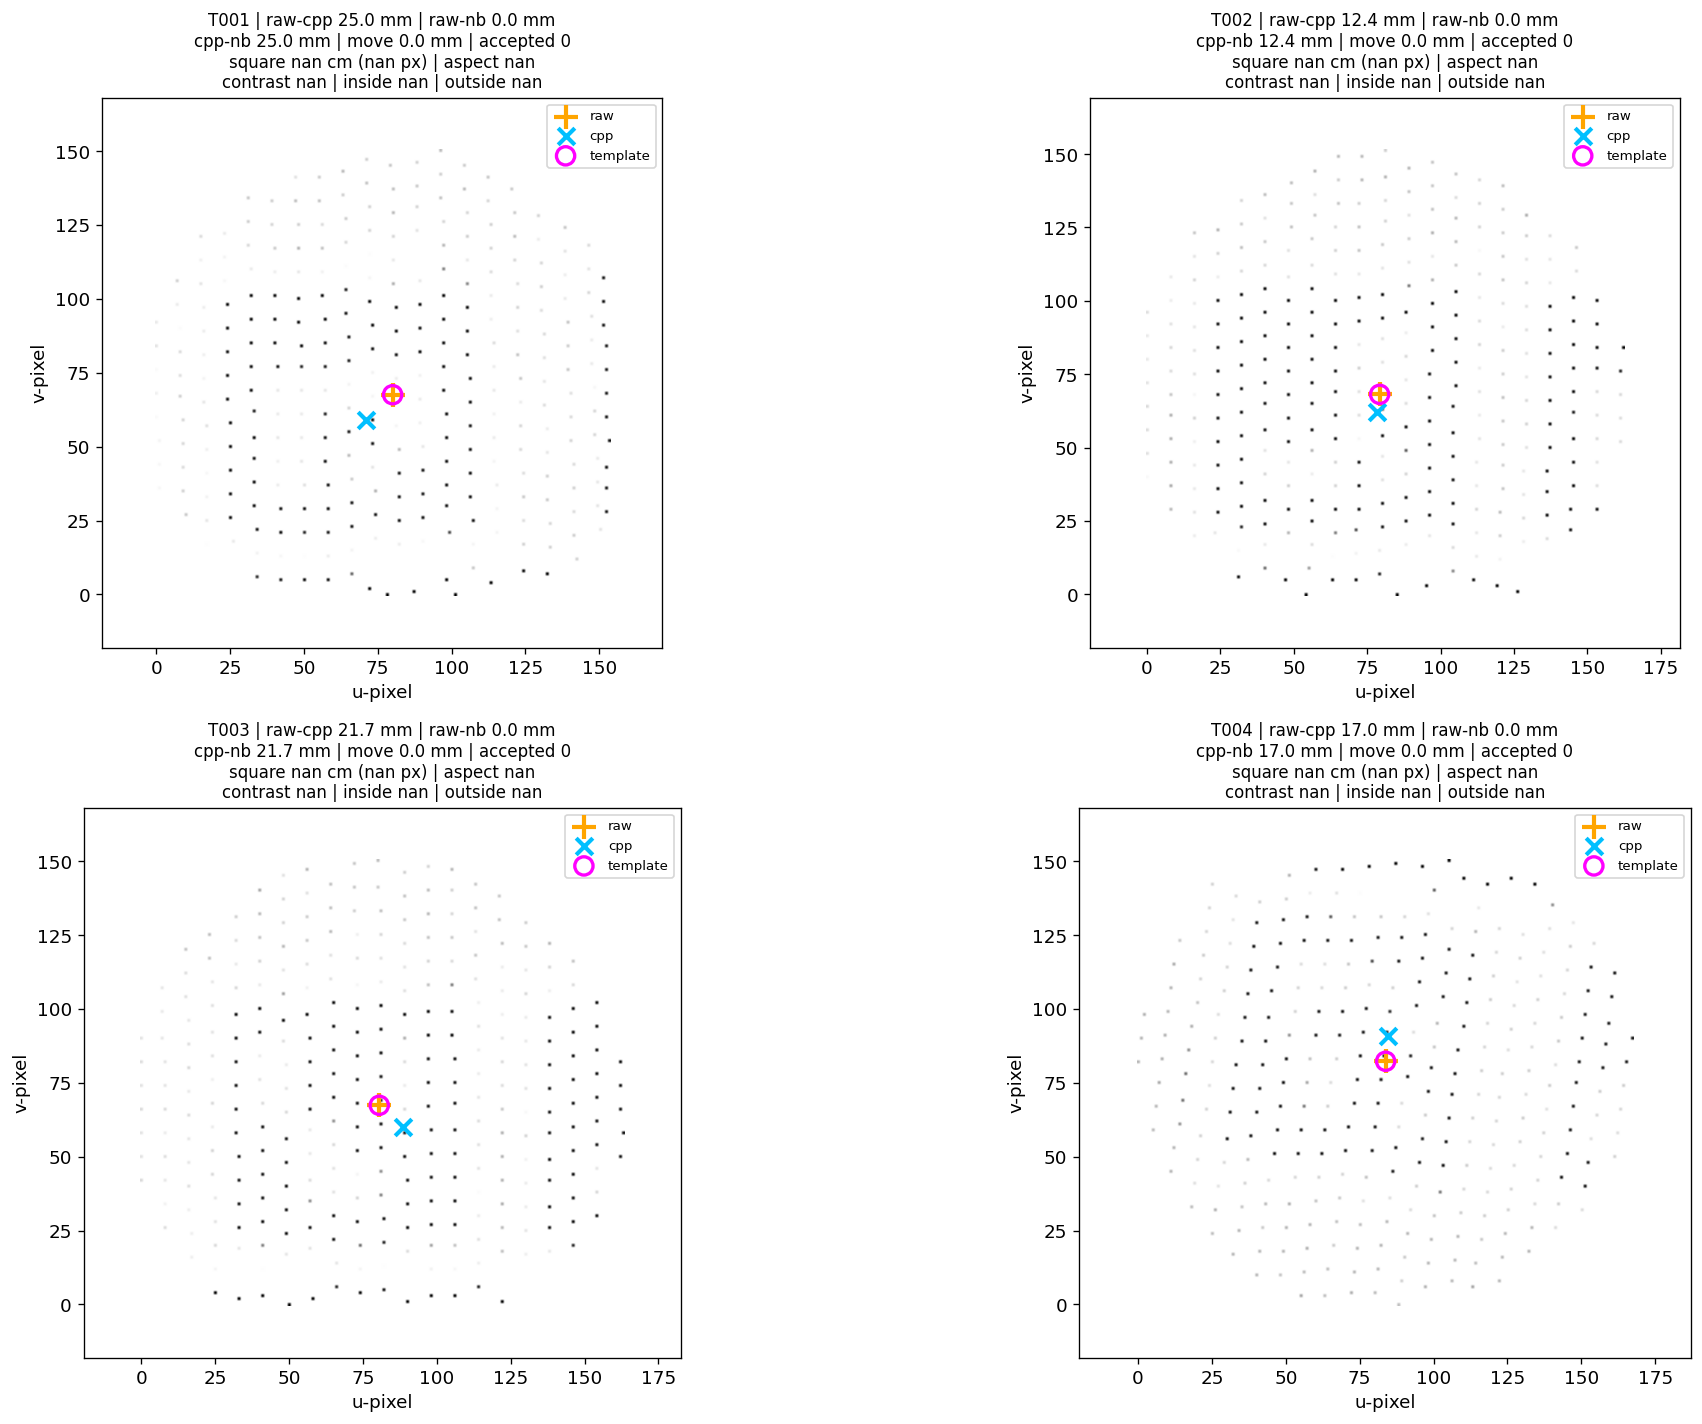

In [530]:
show_all_target_debug(
    notebook_debug,
    raw_centers,
    cpp_centers,
    notebook_centers,
    cols=2,
)

In [531]:
save_centers_json(NOTEBOOK_JSON_PATH, notebook_centers)
summary_payload = {
    "params": PARAMS,
    "notebook_rows": notebook_rows,
    "compare_rows": compare_rows,
}
save_debug_json(NOTEBOOK_DEBUG_PATH, summary_payload)

saved: d:\Conda_envs\TargetDetection\Detection\sample_set2\set2_3m\Registration\reference\debug\targets3d_adjust_notebook.json
saved: d:\Conda_envs\TargetDetection\Detection\sample_set2\set2_3m\Registration\reference\debug\targets3d_adjust_notebook_debug.json


{'id': 'T001', 'ok': True, 'accepted': True, 'reason': 'ok_point_template', 'roi_points': 321, 'template_points': 263, 'delta_from_raw_mm': 31.054574966430664, 'inner_contrast': 0.854404017329216, 'inside_count': 28, 'outside_count': 12, 'point_score': 5.517192739311791, 'dist_raw_cm': 3.099677562713623, 'angle_deg': 89.0, 'tested_candidates': 27333, 'target_total_ms': 1251.130900112912}
{'id': 'T002', 'ok': True, 'accepted': True, 'reason': 'ok_point_template', 'roi_points': 329, 'template_points': 274, 'delta_from_raw_mm': 27.75116729736328, 'inner_contrast': 0.7665382251143456, 'inside_count': 28, 'outside_count': 17, 'point_score': 5.384062163769769, 'dist_raw_cm': 2.7748332023620605, 'angle_deg': 89.5, 'tested_candidates': 27333, 'target_total_ms': 1132.0760000962764}
{'id': 'T003', 'ok': True, 'accepted': True, 'reason': 'ok_point_template', 'roi_points': 329, 'template_points': 276, 'delta_from_raw_mm': 20.262710571289062, 'inner_contrast': 0.7427373379468918, 'inside_count': 19

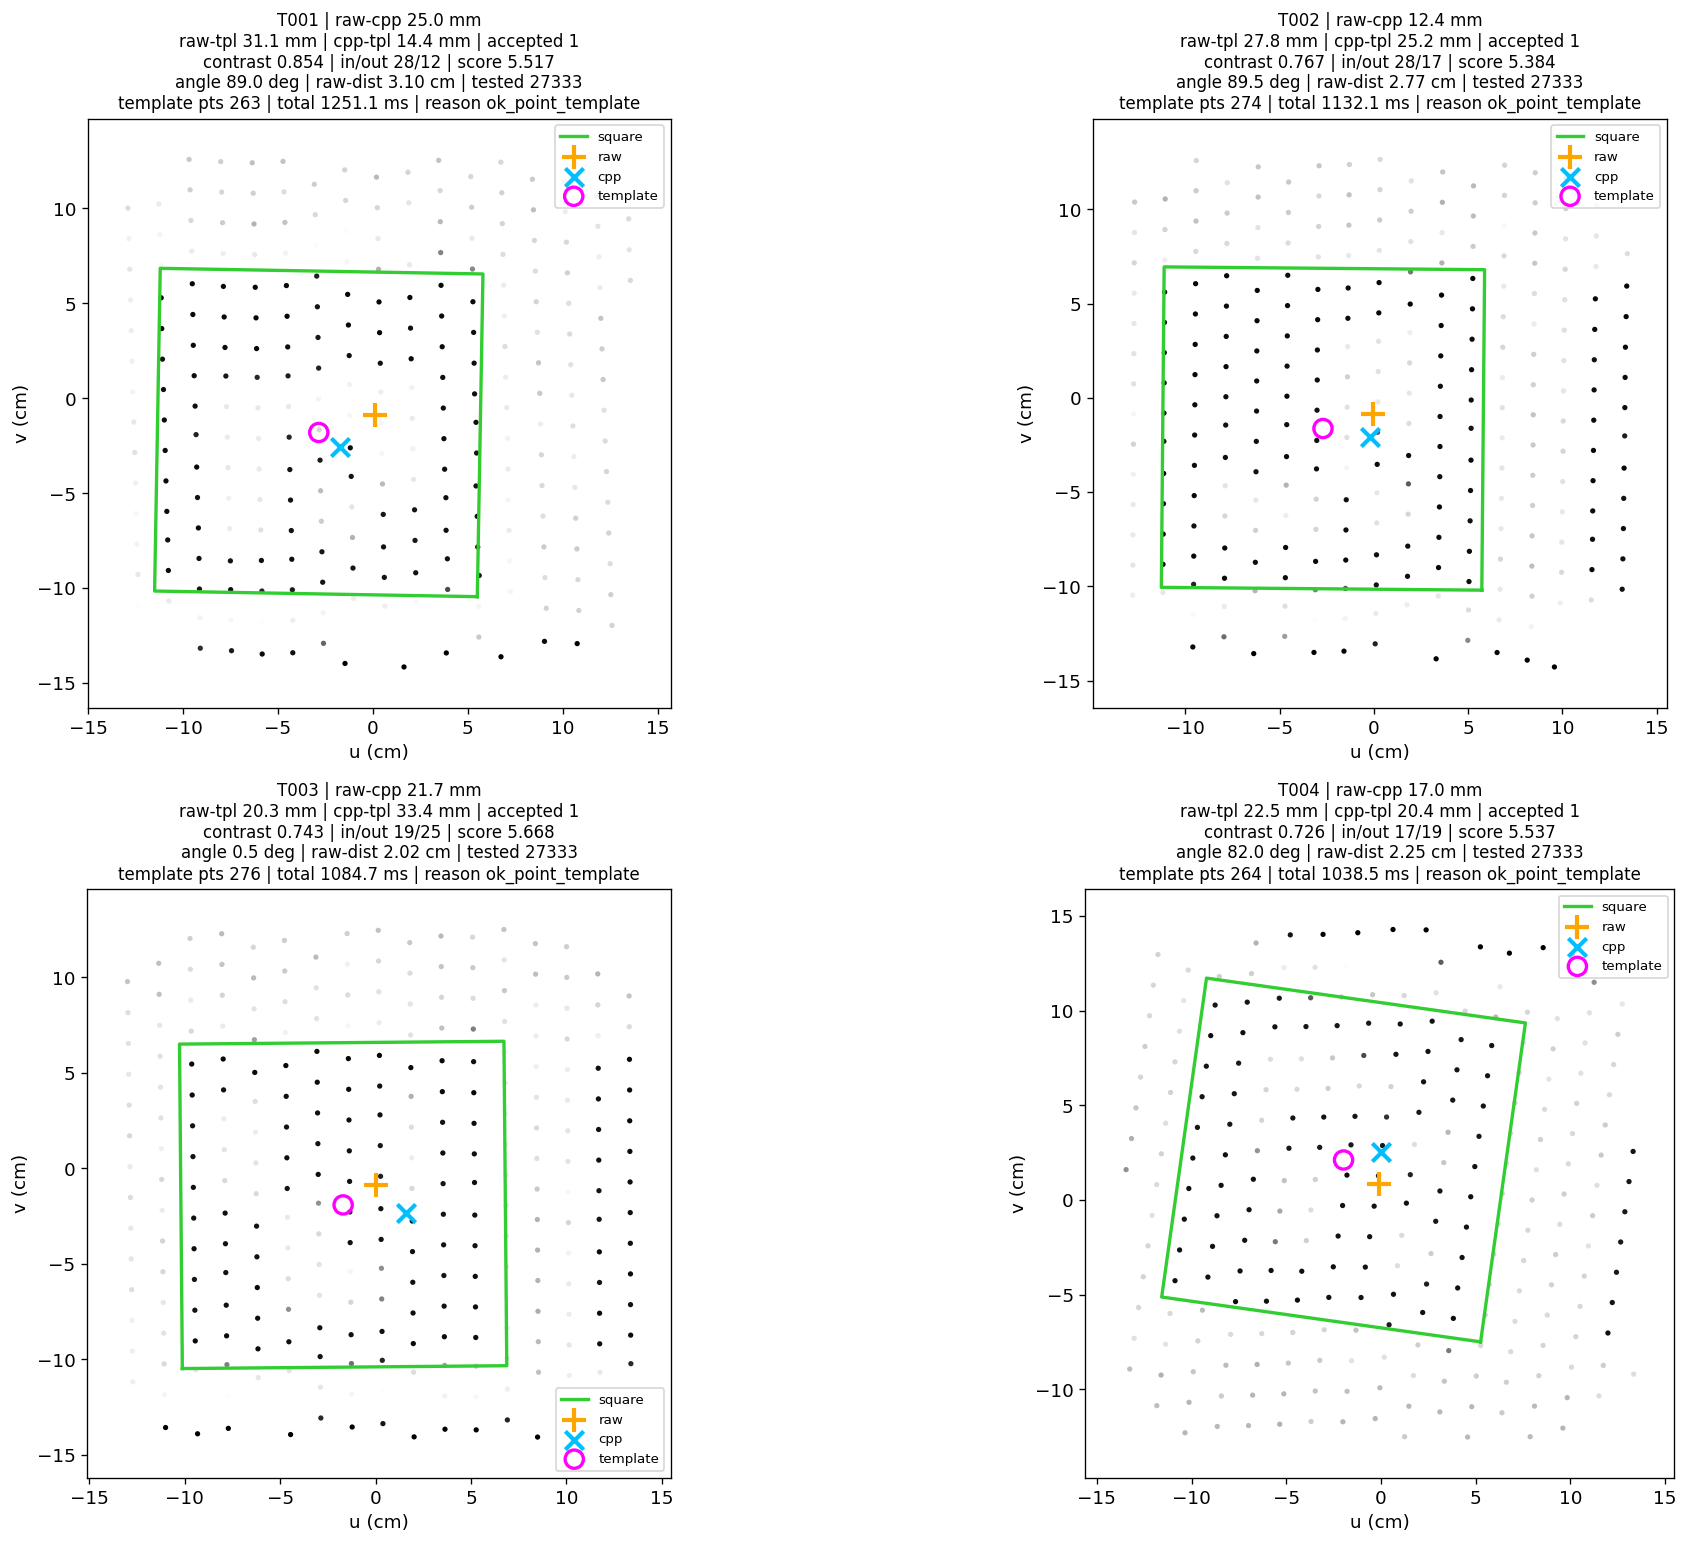

saved: d:\Conda_envs\TargetDetection\Detection\sample_set2\set2_3m\Registration\reference\debug\targets3d_adjust_point_template.json
saved: d:\Conda_envs\TargetDetection\Detection\sample_set2\set2_3m\Registration\reference\debug\targets3d_adjust_point_template_debug.json


In [532]:
import time

POINT_TEMPLATE_PARAMS = {
    "square_side_cm": SQUARE_SIDE_PRIOR_CM,
    "roi_margin_cm": 5.0,
    "roi_scale": 1.0,
    "roi_try_offsets_cm": [0.0, 2.0, 5.0],
    "q_low": 0.02,
    "q_high": 0.98,
    "q_clip": 0.99,
    "min_roi_points": 80,
    "min_template_points": 120,

    # 빠른버전
    # "search_radius_cm": 2.0,
    # "coarse_step_cm": 0.2,
    # "fine_radius_cm": 0.6,
    # "fine_step_cm": 0.1,
    # "coarse_angle_step_deg": 4.0,
    # "fine_angle_half_window_deg": 4.0,
    # "fine_angle_step_deg": 1.0,

    # 중간버전
    "search_radius_cm" : 2.5,
    "coarse_step_cm" : 0.25,
    "fine_radius_cm" : 0.7,
    "fine_step_cm" : 0.06,
    "coarse_angle_step_deg" : 2.0,
    "fine_angle_half_window_deg" : 3.0,
    "fine_angle_step_deg" : 0.5,

    # 고급버전
    # "search_radius_cm" : 3.5,
    # "coarse_step_cm" : 0.2,
    # "fine_radius_cm" : 0.8,
    # "fine_step_cm" : 0.04,
    # "coarse_angle_step_deg" : 1.5,
    # "fine_angle_half_window_deg" : 2.5,
    # "fine_angle_step_deg" : 0.5,

    "inside_band_cm": 1,
    "outside_band_cm": 1,
    "corner_margin_cm": 1.6,
    "pre_crop_margin_cm": 1.5,
    "min_edge_points": 12,
    "min_contrast": 0.02,
    "contrast_weight": 6.0,
    "support_weight": 0.45,
    "balance_weight": 0.75,
    "raw_distance_penalty": 0.35,
    "movement_cap_mm": PARAMS["movement_cap_mm"],
    "min_update_mm": PARAMS["min_update_mm"],
}

POINT_TEMPLATE_JSON_PATH = DEBUG_DIR / "targets3d_adjust_point_template.json"
POINT_TEMPLATE_DEBUG_PATH = DEBUG_DIR / "targets3d_adjust_point_template_debug.json"


def m_to_cm_uv(uv_m):
    uv_m = np.asarray(uv_m, dtype=np.float32)
    return uv_m * 100.0


def cm_to_m_uv(uv_cm):
    uv_cm = np.asarray(uv_cm, dtype=np.float32)
    return uv_cm / 100.0


def rotate_2d(points_cm, angle_deg):
    theta = np.deg2rad(angle_deg)
    c = math.cos(theta)
    s = math.sin(theta)
    rot = np.array([[c, s], [-s, c]], dtype=np.float32)
    return points_cm @ rot.T, rot


def build_square_corners_cm(center_cm, side_cm, angle_deg):
    theta = np.deg2rad(angle_deg)
    c = math.cos(theta)
    s = math.sin(theta)
    basis_u = np.array([c, s], dtype=np.float32)
    basis_v = np.array([-s, c], dtype=np.float32)
    half = 0.5 * float(side_cm)
    corners = np.asarray([
        center_cm - half * basis_u - half * basis_v,
        center_cm + half * basis_u - half * basis_v,
        center_cm + half * basis_u + half * basis_v,
        center_cm - half * basis_u + half * basis_v,
    ], dtype=np.float32)
    return np.vstack([corners, corners[:1]]).astype(np.float32)


def crop_template_points(uv_cm, norm_i, raw_uv_cm, params):
    half = 0.5 * params["square_side_cm"]
    limit = half + params["outside_band_cm"] + params["search_radius_cm"] + params["pre_crop_margin_cm"]
    delta = uv_cm - raw_uv_cm[None, :]
    mask = (np.abs(delta[:, 0]) <= limit) & (np.abs(delta[:, 1]) <= limit)
    return uv_cm[mask], norm_i[mask]


def score_point_template_from_rot(rot_points_cm, norm_i, rot_center_cm, params):
    q = rot_points_cm - rot_center_cm[None, :]
    ax = np.abs(q[:, 0])
    ay = np.abs(q[:, 1])
    max_a = np.maximum(ax, ay)
    min_a = np.minimum(ax, ay)

    half = 0.5 * params["square_side_cm"]
    tangent_limit = max(half - params["corner_margin_cm"], 0.0)

    edge_mask = min_a <= tangent_limit
    inside_mask = edge_mask & (max_a >= (half - params["inside_band_cm"])) & (max_a <= half)
    outside_mask = edge_mask & (max_a > half) & (max_a <= (half + params["outside_band_cm"]))

    inside_count = int(np.count_nonzero(inside_mask))
    outside_count = int(np.count_nonzero(outside_mask))
    if inside_count < params["min_edge_points"] or outside_count < params["min_edge_points"]:
        return None

    inside_mean = float(norm_i[inside_mask].mean())
    outside_mean = float(norm_i[outside_mask].mean())
    contrast = float(outside_mean - inside_mean)
    balance = float(min(inside_count, outside_count) / max(inside_count, outside_count, 1))
    support = float(min(inside_count, outside_count))

    return {
        "inside_mean": inside_mean,
        "outside_mean": outside_mean,
        "inner_contrast": contrast,
        "inside_count": inside_count,
        "outside_count": outside_count,
        "balance": balance,
        "support": support,
    }


def search_direct_point_template(template_uv_cm, template_norm_i, raw_uv_cm, params):
    if len(template_uv_cm) < params["min_template_points"]:
        return None

    rel_uv_cm = template_uv_cm - raw_uv_cm[None, :]
    coarse_offsets = np.arange(
        -params["search_radius_cm"],
        params["search_radius_cm"] + 1e-6,
        params["coarse_step_cm"],
        dtype=np.float32,
    )
    best = None
    tested = 0

    for angle_deg in np.arange(0.0, 90.0, params["coarse_angle_step_deg"], dtype=np.float32):
        rot_points_cm, rot = rotate_2d(rel_uv_cm, float(angle_deg))
        for dy in coarse_offsets:
            for dx in coarse_offsets:
                center_offset_cm = np.array([dx, dy], dtype=np.float32)
                rot_center_cm = center_offset_cm @ rot.T
                info = score_point_template_from_rot(rot_points_cm, template_norm_i, rot_center_cm, params)
                tested += 1
                if info is None:
                    continue

                dist_raw_cm = float(np.linalg.norm(center_offset_cm))
                score = (
                    params["contrast_weight"] * info["inner_contrast"]
                    + params["support_weight"] * math.log1p(info["support"])
                    + params["balance_weight"] * info["balance"]
                    - params["raw_distance_penalty"] * dist_raw_cm
                )

                candidate = {
                    "score": float(score),
                    "center_offset_cm": center_offset_cm.astype(np.float32),
                    "center_cm": (raw_uv_cm + center_offset_cm).astype(np.float32),
                    "angle_deg": float(angle_deg),
                    "dist_raw_cm": dist_raw_cm,
                    **info,
                }
                if best is None or candidate["score"] > best["score"]:
                    best = candidate

    if best is None:
        return None

    fine_offsets = np.arange(
        -params["fine_radius_cm"],
        params["fine_radius_cm"] + 1e-6,
        params["fine_step_cm"],
        dtype=np.float32,
    )
    fine_best = dict(best)
    fine_angles = np.arange(
        best["angle_deg"] - params["fine_angle_half_window_deg"],
        best["angle_deg"] + params["fine_angle_half_window_deg"] + 1e-6,
        params["fine_angle_step_deg"],
        dtype=np.float32,
    )

    for angle_deg in fine_angles:
        wrapped_angle = float(angle_deg % 90.0)
        rot_points_cm, rot = rotate_2d(rel_uv_cm, wrapped_angle)
        for dy in fine_offsets:
            for dx in fine_offsets:
                center_offset_cm = best["center_offset_cm"] + np.array([dx, dy], dtype=np.float32)
                rot_center_cm = center_offset_cm @ rot.T
                info = score_point_template_from_rot(rot_points_cm, template_norm_i, rot_center_cm, params)
                tested += 1
                if info is None:
                    continue

                dist_raw_cm = float(np.linalg.norm(center_offset_cm))
                score = (
                    params["contrast_weight"] * info["inner_contrast"]
                    + params["support_weight"] * math.log1p(info["support"])
                    + params["balance_weight"] * info["balance"]
                    - params["raw_distance_penalty"] * dist_raw_cm
                )

                candidate = {
                    "score": float(score),
                    "center_offset_cm": center_offset_cm.astype(np.float32),
                    "center_cm": (raw_uv_cm + center_offset_cm).astype(np.float32),
                    "angle_deg": wrapped_angle,
                    "dist_raw_cm": dist_raw_cm,
                    **info,
                }
                if candidate["score"] > fine_best["score"]:
                    fine_best = candidate

    fine_best["tested_candidates"] = int(tested)
    fine_best["corners_cm"] = build_square_corners_cm(
        fine_best["center_cm"],
        params["square_side_cm"],
        fine_best["angle_deg"],
    )
    return fine_best


def estimate_one_target_point_template(cloud_data, prev_center, params):
    t_total0 = time.perf_counter()
    base_radius_cm = roi_radius_base_cm(params["square_side_cm"], params["roi_margin_cm"], params["roi_scale"])
    best_result = None

    for extra_cm in params["roi_try_offsets_cm"]:
        radius_cm = base_radius_cm + extra_cm
        roi = extract_roi(cloud_data, prev_center, radius_cm)
        result = {
            "ok": False,
            "accepted": False,
            "reason": "unknown",
            "roi_radius_cm": float(radius_cm),
            "roi_points": int(len(roi["xyz"])),
            "delta_mm": 0.0,
            "center_prev": np.asarray(prev_center, dtype=np.float32),
            "center_candidate": np.asarray(prev_center, dtype=np.float32),
            "center_final": np.asarray(prev_center, dtype=np.float32),
            "roi": roi,
            "square_size_px": np.nan,
            "square_size_cm": float(params["square_side_cm"]),
            "square_aspect": 1.0,
            "dist_raw_px": np.nan,
            "inner_contrast": np.nan,
            "inside_mean": np.nan,
            "outside_mean": np.nan,
            "orth_err_deg": np.nan,
            "hough_strength": np.nan,
            "inside_count": 0,
            "outside_count": 0,
            "balance": np.nan,
            "point_score": np.nan,
            "dist_raw_cm": np.nan,
            "angle_deg": np.nan,
            "tested_candidates": 0,
            "target_total_ms": 0.0,
            "template_points": 0,
        }

        if len(roi["xyz"]) < params["min_roi_points"]:
            result["reason"] = "roi_too_small"
            best_result = result
            continue

        norm_i, lo, hi, clip_hi = normalize_intensity(
            roi["intensity"],
            q_low=params["q_low"],
            q_high=params["q_high"],
            q_clip=params["q_clip"],
        )
        plane = fit_plane_pca(roi["xyz"])
        if plane is None:
            result["reason"] = "plane_fit_failed"
            best_result = result
            continue

        roi_uv_cm = m_to_cm_uv(world_to_uv(roi["xyz"], plane))
        raw_uv_cm = m_to_cm_uv(world_to_uv(prev_center, plane)[0])
        template_uv_cm, template_norm_i = crop_template_points(roi_uv_cm, norm_i, raw_uv_cm, params)

        result["plane"] = plane
        result["roi_uv_cm"] = roi_uv_cm
        result["raw_uv_cm"] = raw_uv_cm
        result["template_uv_cm"] = template_uv_cm
        result["template_norm_i"] = template_norm_i
        result["template_points"] = int(len(template_uv_cm))
        result["lo"] = float(lo)
        result["hi"] = float(hi)
        result["clip_hi"] = float(clip_hi)

        if len(template_uv_cm) < params["min_template_points"]:
            result["reason"] = "template_points_too_small"
            best_result = result
            continue

        best = search_direct_point_template(template_uv_cm, template_norm_i, raw_uv_cm, params)
        if best is None:
            result["reason"] = "no_template_candidate"
            best_result = result
            continue

        center_candidate_uv_m = cm_to_m_uv(best["center_cm"])
        center_candidate = uv_to_world(center_candidate_uv_m, plane)
        delta_mm = float(np.linalg.norm(center_candidate - prev_center) * 1000.0)

        accepted = True
        reason = "ok_point_template"
        if best["inner_contrast"] < params["min_contrast"]:
            accepted = False
            reason = "reject_low_contrast"
        elif delta_mm > params["movement_cap_mm"]:
            accepted = False
            reason = "reject_move_cap"
        elif delta_mm < params["min_update_mm"]:
            accepted = False
            reason = "reject_too_small"

        center_final = center_candidate.astype(np.float32) if accepted else np.asarray(prev_center, dtype=np.float32)
        result.update({
            "ok": True,
            "accepted": bool(accepted),
            "reason": reason,
            "delta_mm": delta_mm,
            "center_candidate": center_candidate.astype(np.float32),
            "center_final": center_final.astype(np.float32),
            "inner_contrast": float(best["inner_contrast"]),
            "inside_mean": float(best["inside_mean"]),
            "outside_mean": float(best["outside_mean"]),
            "inside_count": int(best["inside_count"]),
            "outside_count": int(best["outside_count"]),
            "balance": float(best["balance"]),
            "point_score": float(best["score"]),
            "dist_raw_cm": float(best["dist_raw_cm"]),
            "angle_deg": float(best["angle_deg"]),
            "tested_candidates": int(best["tested_candidates"]),
            "selected_square_corners_cm": best["corners_cm"],
        })
        result["target_total_ms"] = float((time.perf_counter() - t_total0) * 1000.0)

        if accepted:
            return result

        if best_result is None or float(result.get("point_score", -1e9)) > float(best_result.get("point_score", -1e9)):
            best_result = result

    if best_result is None:
        best_result = {
            "ok": False,
            "accepted": False,
            "reason": "no_result",
            "roi_points": 0,
            "delta_mm": 0.0,
            "center_prev": np.asarray(prev_center, dtype=np.float32),
            "center_candidate": np.asarray(prev_center, dtype=np.float32),
            "center_final": np.asarray(prev_center, dtype=np.float32),
            "roi": {"xyz": np.zeros((0, 3), dtype=np.float32)},
            "target_total_ms": float((time.perf_counter() - t_total0) * 1000.0),
        }
    best_result["target_total_ms"] = float((time.perf_counter() - t_total0) * 1000.0)
    return best_result


def run_point_template_all_targets(cloud_data, raw, params):
    centers_out = {}
    debug = {}
    rows = []
    for target_id in sorted(raw.keys()):
        result = estimate_one_target_point_template(cloud_data, raw[target_id], params)
        centers_out[target_id] = np.asarray(result["center_final"], dtype=np.float32)
        debug[target_id] = result
        rows.append({
            "id": target_id,
            "ok": bool(result.get("ok", False)),
            "accepted": bool(result.get("accepted", False)),
            "reason": result.get("reason", ""),
            "roi_points": int(result.get("roi_points", 0)),
            "template_points": int(result.get("template_points", 0)),
            "delta_from_raw_mm": float(result.get("delta_mm", 0.0)),
            "inner_contrast": float(result.get("inner_contrast", np.nan)),
            "inside_count": int(result.get("inside_count", 0)),
            "outside_count": int(result.get("outside_count", 0)),
            "point_score": float(result.get("point_score", np.nan)),
            "dist_raw_cm": float(result.get("dist_raw_cm", np.nan)),
            "angle_deg": float(result.get("angle_deg", np.nan)),
            "tested_candidates": int(result.get("tested_candidates", 0)),
            "target_total_ms": float(result.get("target_total_ms", 0.0)),
        })
    return centers_out, debug, rows


def show_point_template_debug(debug_results, raw, cpp_adjust, template_candidate, cols=2):
    ids = sorted(debug_results.keys())
    rows = math.ceil(len(ids) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(9 * cols, 6.5 * rows))
    axes = np.atleast_1d(axes).ravel()

    for ax in axes:
        ax.axis("off")

    for ax, target_id in zip(axes, ids):
        result = debug_results[target_id]
        ax.axis("on")

        plane = result.get("plane", None)
        uv_cm = result.get("template_uv_cm", np.zeros((0, 2), dtype=np.float32))
        norm_i = result.get("template_norm_i", np.zeros((0,), dtype=np.float32))

        if plane is None or len(uv_cm) == 0:
            roi_xyz = result["roi"]["xyz"] if "roi" in result else np.zeros((0, 3), dtype=np.float32)
            if len(roi_xyz):
                ax.scatter(roi_xyz[:, 0] * 100.0, roi_xyz[:, 2] * 100.0, s=20, c="gray", alpha=0.5)
            title_line1 = f"{target_id} | failed"
            title_line2 = f"reason {result.get('reason', 'unknown')} | roi {result.get('roi_points', 0)}"
            ax.set_title(title_line1 + "\n" + title_line2, fontsize=10)
            ax.set_xlabel("X (cm)")
            ax.set_ylabel("Z (cm)")
            ax.axis("equal")
            continue

        ax.scatter(uv_cm[:, 0], uv_cm[:, 1], c=norm_i, cmap="gray", vmin=0.0, vmax=1.0, s=10, linewidths=0)

        square_cm = result.get("selected_square_corners_cm", np.zeros((0, 2), dtype=np.float32))
        if len(square_cm):
            ax.plot(square_cm[:, 0], square_cm[:, 1], color="limegreen", linewidth=2.0, label="square")

        raw_uv_cm = np.asarray(result.get("raw_uv_cm", np.zeros(2, dtype=np.float32)), dtype=np.float32)
        ax.scatter(raw_uv_cm[0], raw_uv_cm[1], s=220, c="orange", marker="+", linewidths=2.5, label="raw")

        if target_id in cpp_adjust:
            cpp_uv_cm = m_to_cm_uv(world_to_uv(cpp_adjust[target_id], plane)[0])
            ax.scatter(cpp_uv_cm[0], cpp_uv_cm[1], s=120, c="deepskyblue", marker="x", linewidths=2.5, label="cpp")


        if template_candidate is not None and target_id in template_candidate:
            tpl_uv_cm = m_to_cm_uv(world_to_uv(template_candidate[target_id], plane)[0])
            ax.scatter(tpl_uv_cm[0], tpl_uv_cm[1], s=120, facecolors="none", edgecolors="magenta", marker="o", linewidths=2.0, label="template")

        if len(uv_cm):
            xmin = float(np.min(uv_cm[:, 0]))
            xmax = float(np.max(uv_cm[:, 0]))
            ymin = float(np.min(uv_cm[:, 1]))
            ymax = float(np.max(uv_cm[:, 1]))
            dx = max(xmax - xmin, 1.0)
            dy = max(ymax - ymin, 1.0)
            ax.set_xlim(xmin - 0.08 * dx, xmax + 0.08 * dx)
            ax.set_ylim(ymin - 0.08 * dy, ymax + 0.08 * dy)
        ax.set_aspect("equal")

        raw_cpp = np.linalg.norm(raw[target_id] - cpp_adjust[target_id]) * 1000.0 if target_id in raw and target_id in cpp_adjust else np.nan
        raw_tpl = np.linalg.norm(raw[target_id] - template_candidate[target_id]) * 1000.0 if template_candidate is not None and target_id in raw and target_id in template_candidate else np.nan
        cpp_tpl = np.linalg.norm(cpp_adjust[target_id] - template_candidate[target_id]) * 1000.0 if template_candidate is not None and target_id in cpp_adjust and target_id in template_candidate else np.nan

        title_line1 = f"{target_id} | raw-cpp {raw_cpp:.1f} mm"
        title_line2 = f"raw-tpl {raw_tpl:.1f} mm | cpp-tpl {cpp_tpl:.1f} mm | accepted {int(result.get('accepted', False))}"
        title_line3 = f"contrast {result.get('inner_contrast', np.nan):.3f} | in/out {result.get('inside_count', 0)}/{result.get('outside_count', 0)} | score {result.get('point_score', np.nan):.3f}"
        title_line4 = f"angle {result.get('angle_deg', np.nan):.1f} deg | raw-dist {result.get('dist_raw_cm', np.nan):.2f} cm | tested {result.get('tested_candidates', 0)}"
        title_line5 = f"template pts {result.get('template_points', 0)} | total {result.get('target_total_ms', 0.0):.1f} ms | reason {result.get('reason', '')}"
        ax.set_title(title_line1 + "\n" + title_line2 + "\n" + title_line3 + "\n" + title_line4 + "\n" + title_line5, fontsize=10)
        ax.set_xlabel("u (cm)")
        ax.set_ylabel("v (cm)")
        ax.legend(loc="best", fontsize=8)

    plt.tight_layout()
    plt.show()


template_centers, template_debug, template_rows = run_point_template_all_targets(cloud, raw_centers, POINT_TEMPLATE_PARAMS)
point_template_centers = template_centers
point_template_debug = template_debug
point_template_rows = template_rows

show_rows(template_rows, sort_by="target_total_ms", ascending=False)

template_compare_rows = build_compare_table(raw_centers, cpp_centers, template_centers, template_debug)
for row in template_compare_rows:
    row["raw_point_delta_mm"] = row.pop("raw_notebook_delta_mm", np.nan)
    row["cpp_point_delta_mm"] = row.pop("cpp_notebook_delta_mm", np.nan)
point_template_compare_rows = template_compare_rows
show_rows(template_compare_rows, sort_by="cpp_point_delta_mm", ascending=False)

show_point_template_debug(template_debug, raw_centers, cpp_centers, template_centers, cols=2)

save_centers_json(POINT_TEMPLATE_JSON_PATH, template_centers)
point_template_summary_payload = {
    "params": POINT_TEMPLATE_PARAMS,
    "point_template_rows": template_rows,
    "compare_rows": template_compare_rows,
}
save_debug_json(POINT_TEMPLATE_DEBUG_PATH, point_template_summary_payload)


